<a href="https://colab.research.google.com/github/Geckomonc/AI20251-GeraldineAcevedo/blob/main/fase-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importamos todas las librerías necesarias para el análisis, visualización y modelado de datos

In [ ]:
# IMPORTING PACKAGES

# Se utiliza para descomprimir archivos .zip
import zipfile

# DATA PREPROCESSING
import pandas as pd
import datetime
import numpy as np
import re

# VISUALIZATION: Estas bibliotecas permiten crear gráficos de distintos tipos
import folium
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from matplotlib import pyplot as plt
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# MACHINE LEARNING PACKAGES: herramientas de aprendizaje automático supervisado
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Subimos el archivo .zip de la competencia a nuestra carpeta content

Descomprimimos el archivo .zip que contiene nuestros datos para que puedan ser accedidos y analizados dentro de Google Colab

In [ ]:
# Ruta del ZIP subido
zip_path = "/content/pkdd-15-predict-taxi-service-trajectory-i.zip"
extract_path = "/content/kaggle_data"

# Descomprimir el archivo ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


Verificar y recorrer qué archivos fueron extraídos del archivo .zip

In [ ]:
import os

for dirname, _, filenames in os.walk(extract_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/content/kaggle_data/test.csv.zip
/content/kaggle_data/sampleSubmission.csv.zip
/content/kaggle_data/metaData_taxistandsID_name_GPSlocation.csv.zip
/content/kaggle_data/evaluation_script.r
/content/kaggle_data/train.csv.zip


Se define una función personalizada y se utiliza para leer archivos .csv que están comprimidos individualmente dentro de archivos .zip, convirtiéndolos directamente en DataFrames de pandas.

In [ ]:
# Descomprimir individualmente cada .csv.zip
import pandas as pd

def unzip_csv(zip_path, csv_name):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        return pd.read_csv(zip_ref.open(csv_name))

# Ruta base donde se extrajeron los .csv.zip
zip_folder = "/content/kaggle_data"

# Cargar los DataFrames
sample = unzip_csv(f"{zip_folder}/sampleSubmission.csv.zip", "sampleSubmission.csv")
train = unzip_csv(f"{zip_folder}/train.csv.zip", "train.csv")
test = unzip_csv(f"{zip_folder}/test.csv.zip", "test.csv")
location = unzip_csv(f"{zip_folder}/metaData_taxistandsID_name_GPSlocation.csv.zip", "metaData_taxistandsID_name_GPSlocation.csv")


#Predicción de Trayectorias: Porto 🚕

En esta investigación, utilizaremos modelos de aprendizaje supervisado por conjuntos para comprender la trayectoria de los taxis mediante datos de geolocalización. Además, predecir las trayectorias de los taxis no solo ayudará a las empresas a optimizar su sistema de gestión de flotas, sino que también mejorará la eficiencia del combustible y la sostenibilidad. Por lo tanto, para llevar a cabo este amplio estudio de forma eficaz, seguiremos un proceso de cinco pasos.

ÍNDICE

1. Comprensión del negocio

2. Entendimiento de datos

3. Preparación de datos

4. Modelos a usar

5. Evaluación de modelos

6. Predecir y preparar para Kaggle

#Comprensión del negocio

El sector del taxi está en rápido desarrollo. Los servicios de taxi tradicionales se están viendo alterados por nuevos competidores y nuevas tecnologías. Si bien esta evolución ha generado nuevas eficiencias, también ha generado nuevos desafíos.

Un cambio significativo es el uso generalizado de sistemas de despacho electrónico, que en el pasado prácticamente han sustituido a los métodos de despacho por radio VHF. Estos terminales de datos móviles suelen estar instalados en cada vehículo y proporcionan información como la ubicación GPS y el estado del taxímetro. Los sistemas de despacho electrónico permiten ver dónde ha estado un taxi, pero no hacia dónde se dirige. La mayoría de los taxistas que utilizan un sistema de despacho automatizado no especifican el destino final de su viaje.

Por lo tanto, es fundamental poder predecir el destino final de un taxi mientras está en funcionamiento para aumentar la eficiencia de los sistemas informáticos de despacho de taxis. Con frecuencia, un taxi termina su viaje cerca o exactamente en el punto de recogida especificado por un nuevo cliente, especialmente en momentos de alta demanda. Si un despachador supiera dónde finalizarían sus viajes sus taxistas, podría determinar qué taxi enviar a cada solicitud de recogida.

A través de este estudio, construiremos un marco de predicción que permita inferir el destino final de los viajes en taxi en Oporto, Portugal, basándose en sus trayectorias parciales (iniciales).

#Entendimiento de datos

Disponemos de un conjunto de datos completo que representa las rutas de los 442 taxis que operaron en la ciudad portuguesa de Porto durante un año completo (del 01/07/2013 al 30/06/2014) (es decir, un archivo CSV llamado "train.csv"). Cada muestra de datos representa un viaje finalizado. Cada muestra de datos corresponde a un viaje completado. Contiene un total de 10 características distintivas, que son las siguientes:

1.) TRIP_ID: (Cadena) Contiene un identificador único para cada viaje.

2.) CALL_TYPE: (Caracter) Identifica la vía utilizada para solicitar este servicio. Puede contener uno de tres valores posibles: "A" si el viaje se despachó desde la central. "B" si el viaje se solicitó directamente a un taxista en una parada específica. "C" en caso contrario (es decir, un viaje solicitado en una calle aleatoria).

3.) ORIGINCALL: (Entero) Contiene un identificador único para cada número de teléfono utilizado para solicitar, al menos, un servicio. Identifica al cliente del viaje si CALLTYPE="A". De lo contrario, asume un valor nulo.

4.) ORIGINSTAND: (Entero): Contiene un identificador único para la parada de taxis. Identifica el punto de partida del viaje si CALLTYPE="B". De lo contrario, asume un valor nulo. 5.) TAXI_ID: (entero): Contiene un identificador único del taxi volador que realizó cada viaje.

6.) TIMESTAMP: (entero) Marca de tiempo Unix (en segundos). Identifica el inicio del viaje.

7.) DAYTYPE: (carácter) Identifica el tipo de día de inicio del viaje. Asume uno de tres valores posibles: "B" si el viaje comenzó en un día festivo o cualquier otro día especial (por ejemplo, festivos extendidos, festivos flotantes, etc.). "C" si el viaje comenzó un día anterior a un día de tipo B. "A" en caso contrario (por ejemplo, un día normal, laborable o fin de semana).

8.) MISSING_DATA: (Booleano) Es FALSO cuando el flujo de datos GPS está completo y VERDADERO cuando faltan una (o más) ubicaciones.

9.) POLYLINE: (Cadena): Contiene una lista de coordenadas GPS (formato WGS84) mapeadas como una cadena. El inicio y el final de la cadena se identifican con corchetes (es decir, [ y ], respectivamente). Cada par de coordenadas también se identifica con los mismos corchetes que [LONGITUD, LATITUD]. Esta lista contiene un par de coordenadas por cada 15 segundos de viaje. El último elemento de la lista corresponde al destino del viaje, mientras que el primero representa su inicio. EN ESTA SECCIÓN SE REALIZARÁN LOS SIGUIENTES PASOS PARA UNA MEJOR COMPRENSIÓN DE LOS DATOS: Importación de paquetes Carga de datos Obtención de información sobre los datos Realización de estadísticas de resumen Administración de valores nulos Información sobre los tipos de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Muestra el contenido del DataFrame llamado sample

In [ ]:
sample

,TRIP_ID,LATITUDE,LONGITUDE
0,T1,41.146504,-8.611317
1,T2,41.146504,-8.611317
2,T3,41.146504,-8.611317
3,T4,41.146504,-8.611317
4,T5,41.146504,-8.611317
...,...,...,...
315,T323,41.146504,-8.611317
316,T324,41.146504,-8.611317
317,T325,41.146504,-8.611317
318,T326,41.146504,-8.611317


Muestra el contenido del DataFrame llamado train

In [ ]:
train

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."
...,...,...,...,...,...,...,...,...,...
1710665,1404171463620000698,C,NaN,NaN,20000698,1404171463,A,False,"[[-8.612469,41.14602],[-8.612487,41.145993],[-..."
1710666,1404171367620000670,C,NaN,NaN,20000670,1404171367,A,False,"[[-8.610138,41.140845],[-8.610174,41.140935],[..."
1710667,1388745716620000264,C,NaN,NaN,20000264,1388745716,A,False,[]
1710668,1404141826620000248,B,NaN,12.0,20000248,1404141826,A,False,"[[-8.630712,41.154885],[-8.63073,41.154813],[-..."


Muestra el contenido del DataFrame llamado test

In [ ]:
test

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,T1,B,NaN,15.0,20000542,1408039037,A,False,"[[-8.585676,41.148522],[-8.585712,41.148639],[..."
1,T2,B,NaN,57.0,20000108,1408038611,A,False,"[[-8.610876,41.14557],[-8.610858,41.145579],[-..."
2,T3,B,NaN,15.0,20000370,1408038568,A,False,"[[-8.585739,41.148558],[-8.58573,41.148828],[-..."
3,T4,B,NaN,53.0,20000492,1408039090,A,False,"[[-8.613963,41.141169],[-8.614125,41.141124],[..."
4,T5,B,NaN,18.0,20000621,1408039177,A,False,"[[-8.619903,41.148036],[-8.619894,41.148036]]"
...,...,...,...,...,...,...,...,...,...
315,T323,A,70885.0,NaN,20000430,1419171485,A,False,"[[-8.570196,41.159484],[-8.570187,41.158962],[..."
316,T324,B,NaN,53.0,20000020,1419170802,A,False,"[[-8.613873,41.141232],[-8.613882,41.141241],[..."
317,T325,C,NaN,NaN,20000207,1419172121,A,False,"[[-8.6481,41.152536],[-8.647461,41.15241],[-8...."
318,T326,A,76232.0,NaN,20000667,1419171980,A,False,"[[-8.571699,41.156073],[-8.570583,41.155929],[..."


Muestra el contenido del DataFrame llamado location

In [ ]:
location

,ID,Descricao,Latitude,Longitude
0,1,Agra,41.1771457135,-8.609670
1,2,Alameda,41.15618964,-8.591064
2,3,Aldoar,41.1705249231,-8.665876
3,4,Alfândega,41.1437639911,-8.621803
4,5,Amial,41.1835097223,-8.612726
...,...,...,...,...
58,59,Tenente Valadim,41.1607030178,-8.641205
59,60,Trindade,41.1511237005,-8.609843
60,61,Vinte e Quatro de Agosto,41.1493101131,-8.600309
61,62,Viso,41.1778737602,-8.646558


Utilizamos la siguiente línea para mostrar un resumen estructural del DataFrame train

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710670 entries, 0 to 1710669
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   TRIP_ID       int64  
 1   CALL_TYPE     object 
 2   ORIGIN_CALL   float64
 3   ORIGIN_STAND  float64
 4   TAXI_ID       int64  
 5   TIMESTAMP     int64  
 6   DAY_TYPE      object 
 7   MISSING_DATA  bool   
 8   POLYLINE      object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 106.0+ MB


Utilizamos la siguiente línea para mostrar un resumen estructural del DataFrame test

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_ID       320 non-null    object 
 1   CALL_TYPE     320 non-null    object 
 2   ORIGIN_CALL   72 non-null     float64
 3   ORIGIN_STAND  123 non-null    float64
 4   TAXI_ID       320 non-null    int64  
 5   TIMESTAMP     320 non-null    int64  
 6   DAY_TYPE      320 non-null    object 
 7   MISSING_DATA  320 non-null    bool   
 8   POLYLINE      320 non-null    object 
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 20.4+ KB


Utilizamos la siguiente línea para mostrar un resumen estructural del DataFrame sample

In [ ]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TRIP_ID    320 non-null    object 
 1   LATITUDE   320 non-null    float64
 2   LONGITUDE  320 non-null    float64
dtypes: float64(2), object(1)
memory usage: 7.6+ KB


Calculamos el porcentaje de valores nulos (NaN) por cada columna en el DataFrame train.

ORIGIN_CALL tiene un 78.67% de valores faltantes.

ORIGIN_STAND tiene un 52.85% de valores faltantes.

El resto de las columnas (TRIP_ID, CALL_TYPE, TAXI_ID, TIMESTAMP, DAY_TYPE, MISSING_DATA, POLYLINE) no tienen datos faltantes (0.00%).

In [ ]:
Pcent_missing_train = train.isnull().sum() * 100 / len(train)
Pcent_missing_train

,0
TRIP_ID,0.000000
CALL_TYPE,0.000000
ORIGIN_CALL,78.676776
ORIGIN_STAND,52.850111
TAXI_ID,0.000000
TIMESTAMP,0.000000
DAY_TYPE,0.000000
MISSING_DATA,0.000000
POLYLINE,0.000000


Calculamos el porcentaje de valores nulos en el conjunto de datos test.

ORIGIN_CALL tiene aproximadamente 0.0145% de valores faltantes.

ORIGIN_STAND tiene alrededor de 0.0115% de valores faltantes.

Todas las demás columnas (TRIP_ID, CALL_TYPE, TAXI_ID, TIMESTAMP, DAY_TYPE, MISSING_DATA, POLYLINE) tienen 0.0000% de valores nulos.

In [ ]:
Pcent_missing_test = test.isnull().sum() * 100 / len(train)
Pcent_missing_test

,0
TRIP_ID,0.000000
CALL_TYPE,0.000000
ORIGIN_CALL,0.014497
ORIGIN_STAND,0.011516
TAXI_ID,0.000000
TIMESTAMP,0.000000
DAY_TYPE,0.000000
MISSING_DATA,0.000000
POLYLINE,0.000000


Muestra los valores únicos presentes en la columna DAY_TYPE del conjunto de datos train

In [ ]:
train["DAY_TYPE"].unique() # Seems to be just 1 value A as does not add value to the study, threfore we proceed to drop it.

array(['A'], dtype=object)

Muestra los valores únicos presentes en la columna DAY_TYPE del conjunto de datos test

In [ ]:
test["DAY_TYPE"].unique() # Seems to be just 1 value A as does not add value to the study, threfore we proceed to drop it.

array(['A'], dtype=object)

Elimina la columna DAY_TYPE del DataFrame train. Esto se hace porque esa columna contiene únicamente el valor 'A' para todos los registros, lo cual significa que no aporta información útil ni variabilidad al análisis o al modelo de predicción.

In [ ]:
# DROPPING "DAY_TYPE" COLUMN
train = train.drop("DAY_TYPE", axis=1)

Elimina la columna DAY_TYPE del DataFrame test. Esto se hace porque esa columna contiene únicamente el valor 'A' para todos los registros, lo cual significa que no aporta información útil ni variabilidad al análisis o al modelo de predicción.

In [ ]:
# DROPPING "DAY_TYPE" COLUMN
test = test.drop("DAY_TYPE", axis=1)

Muestra el contenido del DataFrame llamado train luego de la eliminación

In [ ]:
train

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."
...,...,...,...,...,...,...,...,...
1710665,1404171463620000698,C,NaN,NaN,20000698,1404171463,False,"[[-8.612469,41.14602],[-8.612487,41.145993],[-..."
1710666,1404171367620000670,C,NaN,NaN,20000670,1404171367,False,"[[-8.610138,41.140845],[-8.610174,41.140935],[..."
1710667,1388745716620000264,C,NaN,NaN,20000264,1388745716,False,[]
1710668,1404141826620000248,B,NaN,12.0,20000248,1404141826,False,"[[-8.630712,41.154885],[-8.63073,41.154813],[-..."


Muestra el contenido del DataFrame llamado test luego de la eliminación

In [ ]:
test

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE
0,T1,B,NaN,15.0,20000542,1408039037,False,"[[-8.585676,41.148522],[-8.585712,41.148639],[..."
1,T2,B,NaN,57.0,20000108,1408038611,False,"[[-8.610876,41.14557],[-8.610858,41.145579],[-..."
2,T3,B,NaN,15.0,20000370,1408038568,False,"[[-8.585739,41.148558],[-8.58573,41.148828],[-..."
3,T4,B,NaN,53.0,20000492,1408039090,False,"[[-8.613963,41.141169],[-8.614125,41.141124],[..."
4,T5,B,NaN,18.0,20000621,1408039177,False,"[[-8.619903,41.148036],[-8.619894,41.148036]]"
...,...,...,...,...,...,...,...,...
315,T323,A,70885.0,NaN,20000430,1419171485,False,"[[-8.570196,41.159484],[-8.570187,41.158962],[..."
316,T324,B,NaN,53.0,20000020,1419170802,False,"[[-8.613873,41.141232],[-8.613882,41.141241],[..."
317,T325,C,NaN,NaN,20000207,1419172121,False,"[[-8.6481,41.152536],[-8.647461,41.15241],[-8...."
318,T326,A,76232.0,NaN,20000667,1419171980,False,"[[-8.571699,41.156073],[-8.570583,41.155929],[..."


Genera un resumen estadístico de las columnas numéricas del DataFrame train. Este resumen incluye:

count: número de valores no nulos en cada columna.

mean: valor promedio.

std: desviación estándar, que indica la dispersión de los datos.

min: valor mínimo.

25%, 50%, 75%: los percentiles (Q1, mediana y Q3).

max: valor máximo.

In [ ]:
# CONDUCTING SUMMARY STATISTICS
train.describe()

,TRIP_ID,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP
count,1.710670e+06,364770.000000,806579.000000,1.710670e+06,1.710670e+06
mean,1.388622e+18,24490.363018,30.272381,2.000035e+07,1.388622e+09
std,9.180944e+15,19624.290043,17.747840,2.112405e+02,9.180944e+06
min,1.372637e+18,2001.000000,1.000000,2.000000e+07,1.372637e+09
25%,1.380731e+18,6593.000000,15.000000,2.000017e+07,1.380731e+09
50%,1.388493e+18,18755.000000,27.000000,2.000034e+07,1.388493e+09
75%,1.396750e+18,40808.000000,49.000000,2.000052e+07,1.396750e+09
max,1.404173e+18,63884.000000,63.000000,2.000098e+07,1.404173e+09


Genera un resumen estadístico de las columnas numéricas del DataFrame test. Este resumen incluye:

count: número de valores no nulos en cada columna.

mean: valor promedio.

std: desviación estándar, que indica la dispersión de los datos.

min: valor mínimo.

25%, 50%, 75%: los percentiles (Q1, mediana y Q3).

max: valor máximo.

In [ ]:
test.describe()

,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP
count,72.000000,123.000000,3.200000e+02,3.200000e+02
mean,38074.083333,29.991870,2.000035e+07,1.412465e+09
std,28528.026167,18.444198,2.065355e+02,3.144882e+06
min,2002.000000,1.000000,2.000000e+07,1.408032e+09
25%,9159.500000,15.000000,2.000018e+07,1.412064e+09
50%,36879.500000,23.000000,2.000035e+07,1.412616e+09
75%,65548.250000,49.000000,2.000052e+07,1.414814e+09
max,86436.000000,63.000000,2.000090e+07,1.419172e+09


La línea de código train.dtypes devuelve los tipos de datos de cada columna en el DataFrame train

In [ ]:
# INSIGHTS INTO TRAIN DATATYPES
train.dtypes

,0
TRIP_ID,int64
CALL_TYPE,object
ORIGIN_CALL,float64
ORIGIN_STAND,float64
TAXI_ID,int64
TIMESTAMP,int64
MISSING_DATA,bool
POLYLINE,object


La línea de código train.dtypes devuelve los tipos de datos de cada columna en el DataFrame test

In [ ]:
# INSIGHTS INTO TEST DATATYPES
test.dtypes

,0
TRIP_ID,object
CALL_TYPE,object
ORIGIN_CALL,float64
ORIGIN_STAND,float64
TAXI_ID,int64
TIMESTAMP,int64
MISSING_DATA,bool
POLYLINE,object


#Preparación de datos

En esta sección, realizaremos los siguientes pasos:
- Investigación de todos los elementos de cada característica
- Decodificación de la firma de tiempo
- Creación de características basadas en el tiempo
- Codificación de características categóricas
- Procesamiento de datos de latitud y longitud
- Visualización múltiple de series temporales
- Estudio del tipo de llamada
- Estudios de correlación
- Visualización de rutas en mapas

 Realizamos un análisis exploratorio básico sobre el conjunto de datos train, específicamente examinando la cantidad de valores únicos presentes en cada columna del DataFrame.

 TRIP_ID, ORIGIN_CALL, TIMESTAMP, TAXI_ID, POLYLINE tienen muchísimos valores únicos.

CALL_TYPE tiene 3 valores únicos: 'A', 'B', y 'C'.

ORIGIN_STAND tiene 64 valores únicos, es decir, hay 64 paradas diferentes.

MISSING_DATA tiene 2 valores: True y False.

In [ ]:
# INVESTIGATING ALL ELEMENTS WITHIN EACH FEATURE IN TRAINING DATA
for colum in train:
    unique_values = np.unique(train[colum])
    nr_values = len(unique_values)
    if nr_values < 10:
        print("The number of unique values for features {} : {} --- {}".format(colum, nr_values,unique_values))
    else:
         print("The number of unique values for features {} : {}".format(colum, nr_values))

The number of unique values for features TRIP_ID : 1710589
The number of unique values for features CALL_TYPE : 3 --- ['A' 'B' 'C']
The number of unique values for features ORIGIN_CALL : 57106
The number of unique values for features ORIGIN_STAND : 64
The number of unique values for features TAXI_ID : 448
The number of unique values for features TIMESTAMP : 1655366
The number of unique values for features MISSING_DATA : 2 --- [False  True]
The number of unique values for features POLYLINE : 1703650


Realizamos un análisis exploratorio básico sobre el conjunto de datos test, específicamente examinando la cantidad de valores únicos presentes en cada columna del DataFrame.

In [ ]:
# INVESTIGATING ALL ELEMENTS WITHIN EACH FEATURE IN TESTING DATA
for colum in test:
    unique_values = np.unique(test[colum])
    nr_values = len(unique_values)
    if nr_values < 10:
        print("The number of unique values for features {} : {} --- {}".format(colum, nr_values,unique_values))
    else:
         print("The number of unique values for features {} : {}".format(colum, nr_values))

The number of unique values for features TRIP_ID : 320
The number of unique values for features CALL_TYPE : 3 --- ['A' 'B' 'C']
The number of unique values for features ORIGIN_CALL : 61
The number of unique values for features ORIGIN_STAND : 40
The number of unique values for features TAXI_ID : 244
The number of unique values for features TIMESTAMP : 315
The number of unique values for features MISSING_DATA : 1 --- [False]
The number of unique values for features POLYLINE : 320


 Decodificamos las marcas de tiempo (TIMESTAMP) del dataset de entrenamiento train, transformándolas en un formato legible y útil para análisis temporales

In [ ]:
# DECODING TIME SIGNATURE TRAIN DATA
train["TIMESTAMP"] = [float(time) for time in train["TIMESTAMP"]]
train["data_time"] = [datetime.datetime.fromtimestamp(time, datetime.timezone.utc) for time in train["TIMESTAMP"]]

 Decodificamos las marcas de tiempo (TIMESTAMP) del dataset de entrenamiento test, transformándolas en un formato legible y útil para análisis temporales

In [ ]:
# DECODING TIME SIGNATURE TEST DATA
test["TIMESTAMP"] = [float(time) for time in test["TIMESTAMP"]]
test["data_time"] = [datetime.datetime.fromtimestamp(time, datetime.timezone.utc) for time in test["TIMESTAMP"]]

Realiza un conteo de cuántas veces aparece cada fecha y hora exacta (timestamp convertido a formato legible) en la columna data_time del DataFrame train. El resultado (como se ve en la imagen) muestra los valores únicos de data_time ordenados de mayor a menor frecuencia, lo que permite identificar cuáles instantes de tiempo tuvieron más viajes registrados.

In [ ]:
train["data_time"].value_counts()

,count
data_time,
2014-04-10 12:57:28+00:00,5
2014-03-27 19:31:22+00:00,5
2014-03-27 18:49:12+00:00,5
2013-10-05 18:11:27+00:00,4
2014-04-10 12:57:01+00:00,4
...,...
2013-11-02 02:08:21+00:00,1
2013-11-02 00:59:15+00:00,1
2013-11-02 01:47:57+00:00,1


Realiza un conteo de cuántas veces aparece cada fecha y hora exacta (timestamp convertido a formato legible) en la columna data_time del DataFrame test. El resultado (como se ve en la imagen) muestra los valores únicos de data_time ordenados de mayor a menor frecuencia, lo que permite identificar cuáles instantes de tiempo tuvieron más viajes registrados.

In [ ]:
test["data_time"].value_counts()

,count
data_time,
2014-08-14 17:49:28+00:00,2
2014-10-06 17:44:33+00:00,2
2014-09-30 08:22:32+00:00,2
2014-09-30 08:25:55+00:00,2
2014-11-01 03:56:49+00:00,2
...,...
2014-09-30 08:23:39+00:00,1
2014-09-30 08:18:38+00:00,1
2014-09-30 08:16:27+00:00,1


Creamos nuevas variables temporales derivadas de la columna data_time en el DataFrame train. A partir del timestamp ya convertido a formato datetime, se extraen componentes específicos para facilitar el análisis y modelado:

year: año del viaje (por ejemplo, 2013 o 2014).

month: mes del año (1 a 12).

day: día del mes (1 a 31).

hour: hora del día (0 a 23).

min: minuto del viaje (0 a 59).

weekday: día de la semana (0 es lunes, 6 es domingo).

Estas nuevas columnas permiten hacer análisis temporales detallados como patrones diarios, semanales o estacionales, y son muy útiles para modelos predictivos que consideren el comportamiento en el tiempo.

In [ ]:
# CREATING TIME BASED FEATURES TRAINING DATA

train["year"] = train["data_time"].dt.year
train["month"] = train["data_time"].dt.month

train["day"] = train["data_time"].dt.day
train["hour"] = train["data_time"].dt.hour
train["min"] = train["data_time"].dt.minute
train["weekday"] = train["data_time"].dt.weekday

Creamos nuevas variables temporales derivadas de la columna data_time en el DataFrame test. A partir del timestamp ya convertido a formato datetime, se extraen componentes específicos para facilitar el análisis y modelado:

year: año del viaje (por ejemplo, 2013 o 2014).

month: mes del año (1 a 12).

day: día del mes (1 a 31).

hour: hora del día (0 a 23).

min: minuto del viaje (0 a 59).

weekday: día de la semana (0 es lunes, 6 es domingo).

Estas nuevas columnas permiten hacer análisis temporales detallados como patrones diarios, semanales o estacionales, y son muy útiles para modelos predictivos que consideren el comportamiento en el tiempo.

In [ ]:
# CREATING TIME BASED FEATURES TESTING DATA

test["year"] = test["data_time"].dt.year
test["month"] = test["data_time"].dt.month

test["day"] = test["data_time"].dt.day
test["hour"] = test["data_time"].dt.hour
test["min"] = test["data_time"].dt.minute
test["weekday"] = test["data_time"].dt.weekday

Realizamos la codificación one-hot de la variable categórica CALL_TYPE en el conjunto de datos train

In [ ]:
# ENCODING CALL TYPE FOR TRAINING DATA TO PREPARE FOR MODELING

encoder = OneHotEncoder(handle_unknown='ignore')

encoder_df = pd.DataFrame(encoder.fit_transform(train[['CALL_TYPE']]).toarray())

final_train = train.join(encoder_df)

final_train.rename(columns={0:'call_type_a', 1:'call_type_b',2:'call_type_c'}, inplace=True)

final_train

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,month,day,hour,min,weekday,call_type_a,call_type_b,call_type_c
0,1372636858620000589,C,NaN,NaN,20000589,1.372637e+09,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[...",2013-07-01 00:00:58+00:00,2013,7,1,0,0,0,0.0,0.0,1.0
1,1372637303620000596,B,NaN,7.0,20000596,1.372637e+09,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[...",2013-07-01 00:08:23+00:00,2013,7,1,0,8,0,0.0,1.0,0.0
2,1372636951620000320,C,NaN,NaN,20000320,1.372637e+09,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-...",2013-07-01 00:02:31+00:00,2013,7,1,0,2,0,0.0,0.0,1.0
3,1372636854620000520,C,NaN,NaN,20000520,1.372637e+09,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[...",2013-07-01 00:00:54+00:00,2013,7,1,0,0,0,0.0,0.0,1.0
4,1372637091620000337,C,NaN,NaN,20000337,1.372637e+09,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-...",2013-07-01 00:04:51+00:00,2013,7,1,0,4,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710665,1404171463620000698,C,NaN,NaN,20000698,1.404171e+09,False,"[[-8.612469,41.14602],[-8.612487,41.145993],[-...",2014-06-30 23:37:43+00:00,2014,6,30,23,37,0,0.0,0.0,1.0
1710666,1404171367620000670,C,NaN,NaN,20000670,1.404171e+09,False,"[[-8.610138,41.140845],[-8.610174,41.140935],[...",2014-06-30 23:36:07+00:00,2014,6,30,23,36,0,0.0,0.0,1.0
1710667,1388745716620000264,C,NaN,NaN,20000264,1.388746e+09,False,[],2014-01-03 10:41:56+00:00,2014,1,3,10,41,4,0.0,0.0,1.0
1710668,1404141826620000248,B,NaN,12.0,20000248,1.404142e+09,False,"[[-8.630712,41.154885],[-8.63073,41.154813],[-...",2014-06-30 15:23:46+00:00,2014,6,30,15,23,0,0.0,1.0,0.0


Realizamos la codificación one-hot de la variable categórica CALL_TYPE en el conjunto de datos test

In [ ]:
# ENCODING CALL TYPE FOR TEST DATA

encoder = OneHotEncoder(handle_unknown='ignore')

encoder_df = pd.DataFrame(encoder.fit_transform(test[['CALL_TYPE']]).toarray())

final_test = test.join(encoder_df)

final_test.rename(columns={0:'call_type_a', 1:'call_type_b',2:'call_type_c'}, inplace=True)

final_test

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,month,day,hour,min,weekday,call_type_a,call_type_b,call_type_c
0,T1,B,NaN,15.0,20000542,1.408039e+09,False,"[[-8.585676,41.148522],[-8.585712,41.148639],[...",2014-08-14 17:57:17+00:00,2014,8,14,17,57,3,0.0,1.0,0.0
1,T2,B,NaN,57.0,20000108,1.408039e+09,False,"[[-8.610876,41.14557],[-8.610858,41.145579],[-...",2014-08-14 17:50:11+00:00,2014,8,14,17,50,3,0.0,1.0,0.0
2,T3,B,NaN,15.0,20000370,1.408039e+09,False,"[[-8.585739,41.148558],[-8.58573,41.148828],[-...",2014-08-14 17:49:28+00:00,2014,8,14,17,49,3,0.0,1.0,0.0
3,T4,B,NaN,53.0,20000492,1.408039e+09,False,"[[-8.613963,41.141169],[-8.614125,41.141124],[...",2014-08-14 17:58:10+00:00,2014,8,14,17,58,3,0.0,1.0,0.0
4,T5,B,NaN,18.0,20000621,1.408039e+09,False,"[[-8.619903,41.148036],[-8.619894,41.148036]]",2014-08-14 17:59:37+00:00,2014,8,14,17,59,3,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,T323,A,70885.0,NaN,20000430,1.419171e+09,False,"[[-8.570196,41.159484],[-8.570187,41.158962],[...",2014-12-21 14:18:05+00:00,2014,12,21,14,18,6,1.0,0.0,0.0
316,T324,B,NaN,53.0,20000020,1.419171e+09,False,"[[-8.613873,41.141232],[-8.613882,41.141241],[...",2014-12-21 14:06:42+00:00,2014,12,21,14,6,6,0.0,1.0,0.0
317,T325,C,NaN,NaN,20000207,1.419172e+09,False,"[[-8.6481,41.152536],[-8.647461,41.15241],[-8....",2014-12-21 14:28:41+00:00,2014,12,21,14,28,6,0.0,0.0,1.0
318,T326,A,76232.0,NaN,20000667,1.419172e+09,False,"[[-8.571699,41.156073],[-8.570583,41.155929],[...",2014-12-21 14:26:20+00:00,2014,12,21,14,26,6,1.0,0.0,0.0


Extraemos la primera coordenada GPS (longitud y latitud) de cada viaje contenido en la columna POLYLINE del conjunto de datos final_train. El objetivo es obtener el punto de inicio de cada trayecto para poder graficarlo en un mapa o utilizarlo como feature en un modelo predictivo.

In [ ]:
# EXTRACTING 1st LATITUDE FOR PLOTTING IT ON THE MAP FROM TRAINING DATA

# 1st lon
lists_1st_lon = []
for i in range(0,len(final_train["POLYLINE"])):
    if final_train["POLYLINE"][i] == '[]':
        k=0
        lists_1st_lon.append(k)
    else:
        k = re.sub(r"[[|[|]|]|]]", "", final_train["POLYLINE"][i]).split(",")[0]
        lists_1st_lon.append(k)

final_train["lon_1st"] = lists_1st_lon

# 1st lat
lists_1st_lat = []
for i in range(0,len(final_train["POLYLINE"])):
    if final_train["POLYLINE"][i] == '[]':
        k=0
        lists_1st_lat.append(k)
    else:
        k = re.sub(r"[[|[|]|]|]]", "", final_train["POLYLINE"][i]).split(",")[1]
        lists_1st_lat.append(k)

final_train["lat_1st"] = lists_1st_lat

Extraemos la última coordenada GPS (longitud y latitud) de cada trayecto registrado en la columna POLYLINE del DataFrame final_train. Esto representa el destino final del viaje

In [ ]:
# EXTRACTING Last LONGITUDE FOR PLOTTING IT ON THE MAP FROM TRAINING DATA

# last long
lists_last_lon = []
for i in range(0,len(final_train["POLYLINE"])):
        if final_train["POLYLINE"][i] == '[]':
            k=0
            lists_last_lon.append(k)
        else:
            k = re.sub(r"[[|[|]|]|]]", "", final_train["POLYLINE"][i]).split(",")[-2]
            lists_last_lon.append(k)

final_train["lon_last"] = lists_last_lon

# last lat
lists_last_lat = []
for i in range(0,len(final_train["POLYLINE"])):
    if final_train["POLYLINE"][i] == '[]':
        k=0
        lists_last_lat.append(k)
    else:
        k = re.sub(r"[[|[|]|]|]]", "", final_train["POLYLINE"][i]).split(",")[-1]
        lists_last_lat.append(k)

final_train["lat_last"] = lists_last_lat

Mostramos el DataFrame final_train después de haber pasado por múltiples etapas de preparación y enriquecimiento de datos. Podemos observar que final_train contiene 22 columnas y 1.710.670 filas.

In [ ]:
final_train

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,...,hour,min,weekday,call_type_a,call_type_b,call_type_c,lon_1st,lat_1st,lon_last,lat_last
0,1372636858620000589,C,NaN,NaN,20000589,1.372637e+09,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[...",2013-07-01 00:00:58+00:00,2013,...,0,0,0,0.0,0.0,1.0,-8.618643,41.141412,-8.630838,41.154489
1,1372637303620000596,B,NaN,7.0,20000596,1.372637e+09,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[...",2013-07-01 00:08:23+00:00,2013,...,0,8,0,0.0,1.0,0.0,-8.639847,41.159826,-8.66574,41.170671
2,1372636951620000320,C,NaN,NaN,20000320,1.372637e+09,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-...",2013-07-01 00:02:31+00:00,2013,...,0,2,0,0.0,0.0,1.0,-8.612964,41.140359,-8.61597,41.14053
3,1372636854620000520,C,NaN,NaN,20000520,1.372637e+09,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[...",2013-07-01 00:00:54+00:00,2013,...,0,0,0,0.0,0.0,1.0,-8.574678,41.151951,-8.607996,41.142915
4,1372637091620000337,C,NaN,NaN,20000337,1.372637e+09,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-...",2013-07-01 00:04:51+00:00,2013,...,0,4,0,0.0,0.0,1.0,-8.645994,41.18049,-8.687268,41.178087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710665,1404171463620000698,C,NaN,NaN,20000698,1.404171e+09,False,"[[-8.612469,41.14602],[-8.612487,41.145993],[-...",2014-06-30 23:37:43+00:00,2014,...,23,37,0,0.0,0.0,1.0,-8.612469,41.14602,-8.611344,41.171013
1710666,1404171367620000670,C,NaN,NaN,20000670,1.404171e+09,False,"[[-8.610138,41.140845],[-8.610174,41.140935],[...",2014-06-30 23:36:07+00:00,2014,...,23,36,0,0.0,0.0,1.0,-8.610138,41.140845,-8.627454,41.158755
1710667,1388745716620000264,C,NaN,NaN,20000264,1.388746e+09,False,[],2014-01-03 10:41:56+00:00,2014,...,10,41,4,0.0,0.0,1.0,0,0,0,0
1710668,1404141826620000248,B,NaN,12.0,20000248,1.404142e+09,False,"[[-8.630712,41.154885],[-8.63073,41.154813],[-...",2014-06-30 15:23:46+00:00,2014,...,15,23,0,0.0,1.0,0.0,-8.630712,41.154885,-8.587026,41.173524


Filtramos el DataFrame final_train para eliminar las filas donde la longitud final (lon_last) sea igual a 0, y almacenamos el resultado en un nuevo DataFrame llamado train.

In [ ]:
# DELETE LON & LAT HAVE "0"
train = final_train.query("lon_last != 0")

Convertimos explícitamente el tipo de datos de varias columnas clave del DataFrame train a los tipos adecuados para modelado

In [ ]:
## CHANGING DATA TYPE FOR MODELING TRAINING DATA

train["lon_1st"] = [float(k) for k in train["lon_1st"]]
train["lat_1st"] = [float(k) for k in train["lat_1st"]]
train["lon_last"] = [float(k) for k in train["lon_last"]]
train["lat_last"] = [float(k) for k in train["lat_last"]]
train['call_type_a']= [int(k) for k in train["call_type_a"]]
train['call_type_b'] =[int(k) for k in train["call_type_b"]]
train['call_type_c']= [int(k) for k in train["call_type_c"]]

Se realizaron las transformaciones y limpieza:

El DataFrame tiene 22 columnas y 1,704,769 registros válidos.

Las columnas lon_1st, lat_1st, lon_last, lat_last fueron correctamente generadas desde la columna POLYLINE.

Se eliminaron los registros con coordenadas vacías (0) en lon_last y lat_last.

Se conservaron las variables temporales (year, month, day, hour, min, weekday) y las columnas de codificación call_type_a, call_type_b, call_type_c.

In [ ]:
train

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,...,hour,min,weekday,call_type_a,call_type_b,call_type_c,lon_1st,lat_1st,lon_last,lat_last
0,1372636858620000589,C,NaN,NaN,20000589,1.372637e+09,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[...",2013-07-01 00:00:58+00:00,2013,...,0,0,0,0,0,1,-8.618643,41.141412,-8.630838,41.154489
1,1372637303620000596,B,NaN,7.0,20000596,1.372637e+09,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[...",2013-07-01 00:08:23+00:00,2013,...,0,8,0,0,1,0,-8.639847,41.159826,-8.665740,41.170671
2,1372636951620000320,C,NaN,NaN,20000320,1.372637e+09,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-...",2013-07-01 00:02:31+00:00,2013,...,0,2,0,0,0,1,-8.612964,41.140359,-8.615970,41.140530
3,1372636854620000520,C,NaN,NaN,20000520,1.372637e+09,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[...",2013-07-01 00:00:54+00:00,2013,...,0,0,0,0,0,1,-8.574678,41.151951,-8.607996,41.142915
4,1372637091620000337,C,NaN,NaN,20000337,1.372637e+09,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-...",2013-07-01 00:04:51+00:00,2013,...,0,4,0,0,0,1,-8.645994,41.180490,-8.687268,41.178087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710663,1388660427620000585,C,NaN,NaN,20000585,1.388660e+09,False,"[[-8.60697,41.162283],[-8.60697,41.16231],[-8....",2014-01-02 11:00:27+00:00,2014,...,11,0,3,0,0,1,-8.606970,41.162283,-8.608158,41.162382
1710665,1404171463620000698,C,NaN,NaN,20000698,1.404171e+09,False,"[[-8.612469,41.14602],[-8.612487,41.145993],[-...",2014-06-30 23:37:43+00:00,2014,...,23,37,0,0,0,1,-8.612469,41.146020,-8.611344,41.171013
1710666,1404171367620000670,C,NaN,NaN,20000670,1.404171e+09,False,"[[-8.610138,41.140845],[-8.610174,41.140935],[...",2014-06-30 23:36:07+00:00,2014,...,23,36,0,0,0,1,-8.610138,41.140845,-8.627454,41.158755
1710668,1404141826620000248,B,NaN,12.0,20000248,1.404142e+09,False,"[[-8.630712,41.154885],[-8.63073,41.154813],[-...",2014-06-30 15:23:46+00:00,2014,...,15,23,0,0,1,0,-8.630712,41.154885,-8.587026,41.173524


Extraemos la primera coordenada GPS (longitud y latitud) de cada viaje contenido en la columna POLYLINE del conjunto de datos final_test. El objetivo es obtener el punto de inicio de cada trayecto para poder graficarlo en un mapa o utilizarlo como feature en un modelo predictivo.

In [ ]:
# EXTRACTING 1st LATITUDE FROM TESTING DATA

# 1st lon
lists_1st_lon = []
for i in range(0,len(final_test["POLYLINE"])):
    if final_test["POLYLINE"][i] == '[]':
        k=0
        lists_1st_lon.append(k)
    else:
        k = re.sub(r"[[|[|]|]|]]", "", final_test["POLYLINE"][i]).split(",")[0]
        lists_1st_lon.append(k)

final_test["lon_1st"] = lists_1st_lon

# 1st lat
lists_1st_lat = []
for i in range(0,len(final_test["POLYLINE"])):
    if final_test["POLYLINE"][i] == '[]':
        k=0
        lists_1st_lat.append(k)
    else:
        k = re.sub(r"[[|[|]|]|]]", "", final_test["POLYLINE"][i]).split(",")[1]
        lists_1st_lat.append(k)

final_test["lat_1st"] = lists_1st_lat

Extraemos la última coordenada GPS (longitud y latitud) de cada trayecto registrado en la columna POLYLINE del DataFrame final_test. Esto representa el destino final del viaje.

In [ ]:
# EXTRACTING Last LONGITUDE FROM TESTING DATA

lists_last_lon = []
for i in range(0,len(final_test["POLYLINE"])):
        if final_test["POLYLINE"][i] == '[]':
            k=0
            lists_last_lon.append(k)
        else:
            k = re.sub(r"[[|[|]|]|]]", "", final_test["POLYLINE"][i]).split(",")[-2]
            lists_last_lon.append(k)

final_test["lon_last"] = lists_last_lon

# last lat
lists_last_lat = []
for i in range(0,len(final_test["POLYLINE"])):
    if final_test["POLYLINE"][i] == '[]':
        k=0
        lists_last_lat.append(k)
    else:
        k = re.sub(r"[[|[|]|]|]]", "", final_test["POLYLINE"][i]).split(",")[-1]
        lists_last_lat.append(k)

final_test["lat_last"] = lists_last_lat

Mostramos el DataFrame final_test después de haber pasado por múltiples etapas de preparación y enriquecimiento de datos.

In [ ]:
final_test

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,...,hour,min,weekday,call_type_a,call_type_b,call_type_c,lon_1st,lat_1st,lon_last,lat_last
0,T1,B,NaN,15.0,20000542,1.408039e+09,False,"[[-8.585676,41.148522],[-8.585712,41.148639],[...",2014-08-14 17:57:17+00:00,2014,...,17,57,3,0.0,1.0,0.0,-8.585676,41.148522,-8.584884,41.146623
1,T2,B,NaN,57.0,20000108,1.408039e+09,False,"[[-8.610876,41.14557],[-8.610858,41.145579],[-...",2014-08-14 17:50:11+00:00,2014,...,17,50,3,0.0,1.0,0.0,-8.610876,41.14557,-8.601894,41.163597
2,T3,B,NaN,15.0,20000370,1.408039e+09,False,"[[-8.585739,41.148558],[-8.58573,41.148828],[-...",2014-08-14 17:49:28+00:00,2014,...,17,49,3,0.0,1.0,0.0,-8.585739,41.148558,-8.574903,41.167719
3,T4,B,NaN,53.0,20000492,1.408039e+09,False,"[[-8.613963,41.141169],[-8.614125,41.141124],[...",2014-08-14 17:58:10+00:00,2014,...,17,58,3,0.0,1.0,0.0,-8.613963,41.141169,-8.614638,41.14098
4,T5,B,NaN,18.0,20000621,1.408039e+09,False,"[[-8.619903,41.148036],[-8.619894,41.148036]]",2014-08-14 17:59:37+00:00,2014,...,17,59,3,0.0,1.0,0.0,-8.619903,41.148036,-8.619894,41.148036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,T323,A,70885.0,NaN,20000430,1.419171e+09,False,"[[-8.570196,41.159484],[-8.570187,41.158962],[...",2014-12-21 14:18:05+00:00,2014,...,14,18,6,1.0,0.0,0.0,-8.570196,41.159484,-8.593308,41.151051
316,T324,B,NaN,53.0,20000020,1.419171e+09,False,"[[-8.613873,41.141232],[-8.613882,41.141241],[...",2014-12-21 14:06:42+00:00,2014,...,14,6,6,0.0,1.0,0.0,-8.613873,41.141232,-8.629785,41.152671
317,T325,C,NaN,NaN,20000207,1.419172e+09,False,"[[-8.6481,41.152536],[-8.647461,41.15241],[-8....",2014-12-21 14:28:41+00:00,2014,...,14,28,6,0.0,0.0,1.0,-8.6481,41.152536,-8.643303,41.154327
318,T326,A,76232.0,NaN,20000667,1.419172e+09,False,"[[-8.571699,41.156073],[-8.570583,41.155929],[...",2014-12-21 14:26:20+00:00,2014,...,14,26,6,1.0,0.0,0.0,-8.571699,41.156073,-8.569206,41.167629


Filtramos el DataFrame final_test para eliminar las filas donde la longitud final (lon_last) sea igual a 0, y almacenamos el resultado en un nuevo DataFrame llamado test.

In [ ]:
# Delete lon & lat have "0".
test = final_test.query("lon_last != 0")

Convertimos explícitamente el tipo de datos de varias columnas clave del DataFrame test a los tipos adecuados para modelado

In [ ]:
## CHANGING DATA TYPE FOR TESTING DATA

test["lon_1st"] = [float(k) for k in test["lon_1st"]]
test["lat_1st"] = [float(k) for k in test["lat_1st"]]
test["lon_last"] = [float(k) for k in test["lon_last"]]
test["lat_last"] = [float(k) for k in test["lat_last"]]
test['call_type_a']= [int(k) for k in test["call_type_a"]]
test['call_type_b'] =[int(k) for k in test["call_type_b"]]
test['call_type_c']= [int(k) for k in test["call_type_c"]]

Se realizaron las transformaciones y limpieza:

In [ ]:
test

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,...,hour,min,weekday,call_type_a,call_type_b,call_type_c,lon_1st,lat_1st,lon_last,lat_last
0,T1,B,NaN,15.0,20000542,1.408039e+09,False,"[[-8.585676,41.148522],[-8.585712,41.148639],[...",2014-08-14 17:57:17+00:00,2014,...,17,57,3,0,1,0,-8.585676,41.148522,-8.584884,41.146623
1,T2,B,NaN,57.0,20000108,1.408039e+09,False,"[[-8.610876,41.14557],[-8.610858,41.145579],[-...",2014-08-14 17:50:11+00:00,2014,...,17,50,3,0,1,0,-8.610876,41.145570,-8.601894,41.163597
2,T3,B,NaN,15.0,20000370,1.408039e+09,False,"[[-8.585739,41.148558],[-8.58573,41.148828],[-...",2014-08-14 17:49:28+00:00,2014,...,17,49,3,0,1,0,-8.585739,41.148558,-8.574903,41.167719
3,T4,B,NaN,53.0,20000492,1.408039e+09,False,"[[-8.613963,41.141169],[-8.614125,41.141124],[...",2014-08-14 17:58:10+00:00,2014,...,17,58,3,0,1,0,-8.613963,41.141169,-8.614638,41.140980
4,T5,B,NaN,18.0,20000621,1.408039e+09,False,"[[-8.619903,41.148036],[-8.619894,41.148036]]",2014-08-14 17:59:37+00:00,2014,...,17,59,3,0,1,0,-8.619903,41.148036,-8.619894,41.148036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,T323,A,70885.0,NaN,20000430,1.419171e+09,False,"[[-8.570196,41.159484],[-8.570187,41.158962],[...",2014-12-21 14:18:05+00:00,2014,...,14,18,6,1,0,0,-8.570196,41.159484,-8.593308,41.151051
316,T324,B,NaN,53.0,20000020,1.419171e+09,False,"[[-8.613873,41.141232],[-8.613882,41.141241],[...",2014-12-21 14:06:42+00:00,2014,...,14,6,6,0,1,0,-8.613873,41.141232,-8.629785,41.152671
317,T325,C,NaN,NaN,20000207,1.419172e+09,False,"[[-8.6481,41.152536],[-8.647461,41.15241],[-8....",2014-12-21 14:28:41+00:00,2014,...,14,28,6,0,0,1,-8.648100,41.152536,-8.643303,41.154327
318,T326,A,76232.0,NaN,20000667,1.419172e+09,False,"[[-8.571699,41.156073],[-8.570583,41.155929],[...",2014-12-21 14:26:20+00:00,2014,...,14,26,6,1,0,0,-8.571699,41.156073,-8.569206,41.167629


Estudio de series temporales en el que se analiza la distribución de los viajes de taxi por hora del día, comparando los años 2013 y 2014.

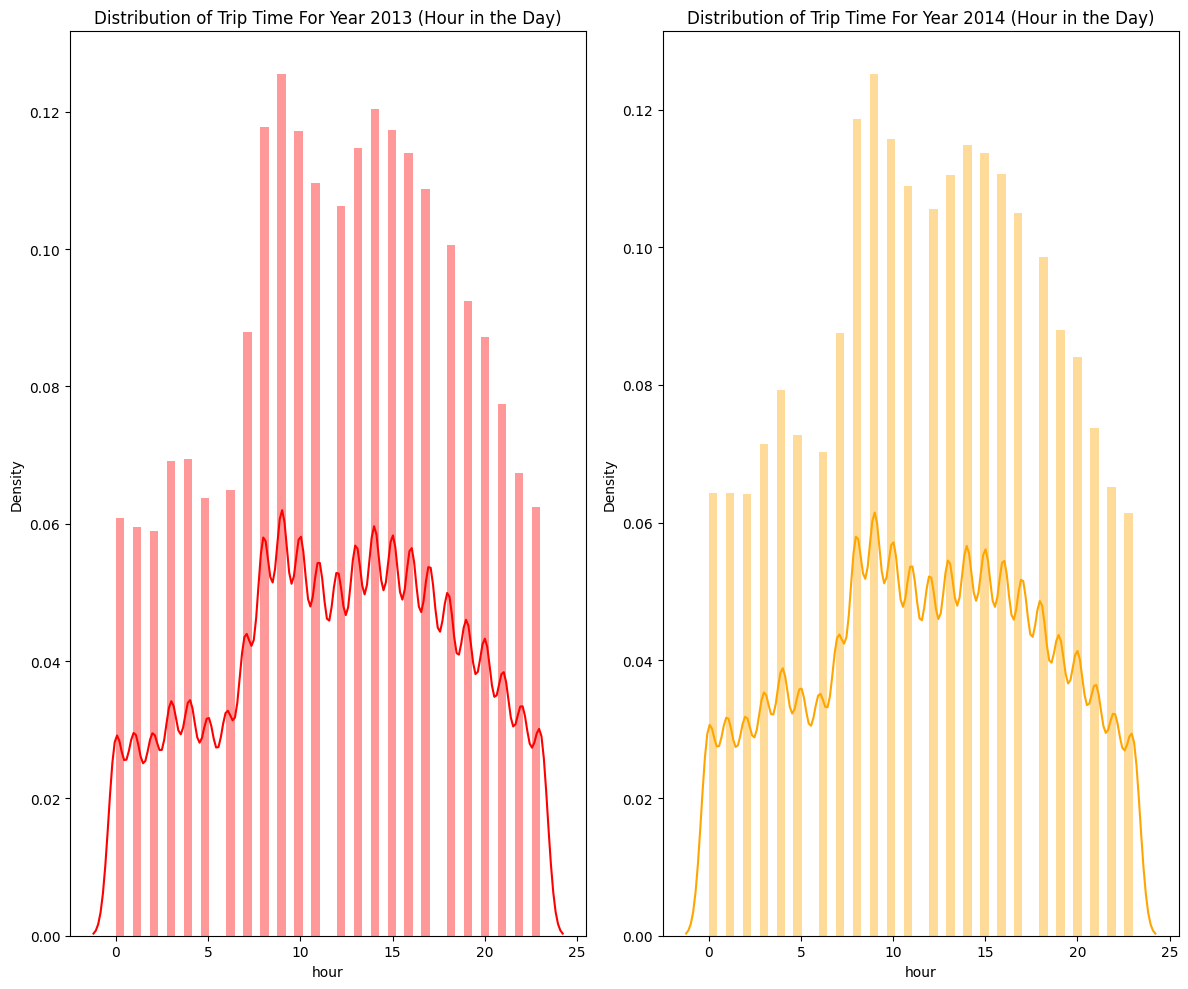

In [ ]:
# TIME SERIES STUDY

year = [2013,2014]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,10))
axs = axs.flatten()

colors = ['red', 'orange']
for i, year in enumerate(year):
    # Filter for each year observations and reset index
    data2 = train.loc[train.year == year,:]
    sns.distplot(data2.hour, ax=axs[i], color=colors[i%2])
    axs[i].set_title(f'Distribution of Trip Time For Year {year} (Hour in the Day)')

plt.tight_layout()
plt.show()

Nota:
- **De la distribución anterior del tiempo de viaje por año podemos ver que la demanda de taxis fue similar en 2013 y 2014.**

 Análisis de distribución horaria mensual para los viajes de taxi registrados en Porto.

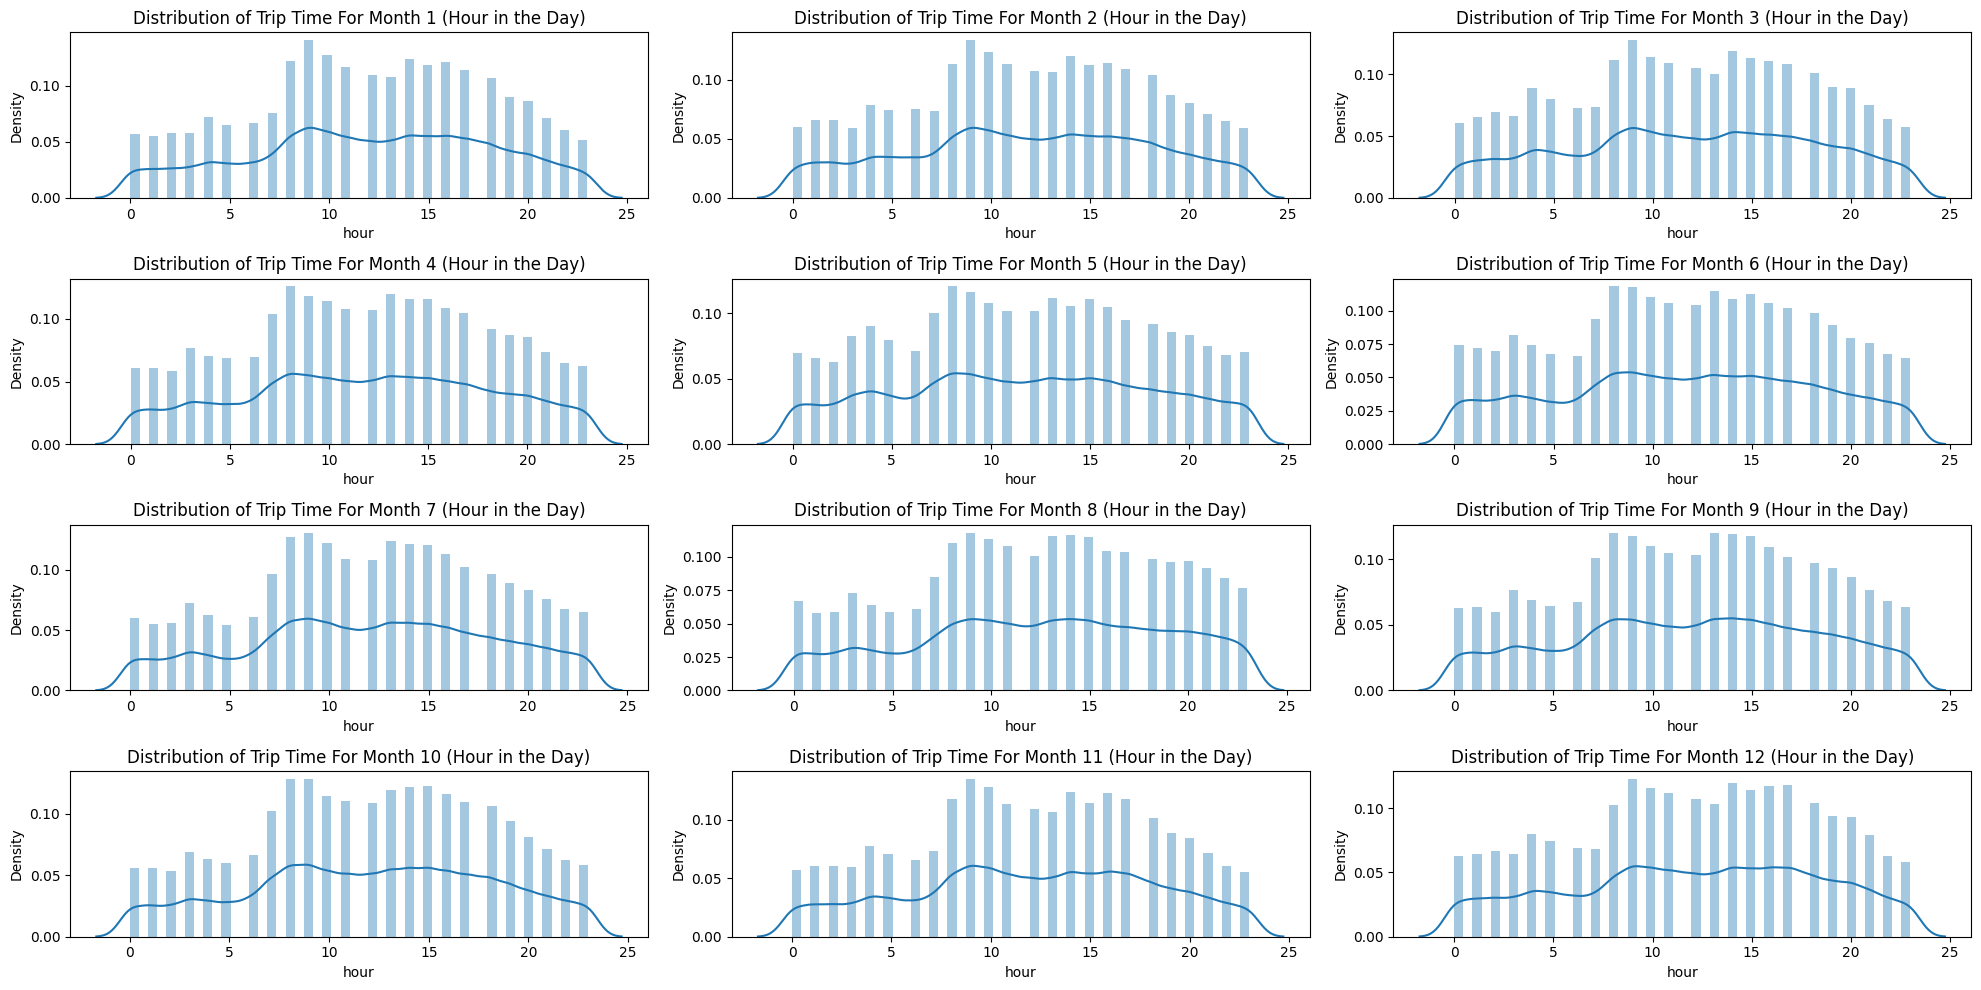

In [ ]:
# TIME SERIES STUDY
months = [1,2,3,4,5,6,7,8,9,10,11,12]

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(20,10))
axs = axs.flatten()

for i, month in enumerate(months):
    # Filter for each month observations and reset index
    data2 = train.loc[train.month == month,:].reset_index(drop = True)
    sns.distplot(data2.hour, ax=axs[i])
    axs[i].set_title(f'Distribution of Trip Time For Month {month} (Hour in the Day)')

plt.tight_layout()
plt.show()

Análisis de distribución horaria semanal para los viajes de taxi registrados en Porto.

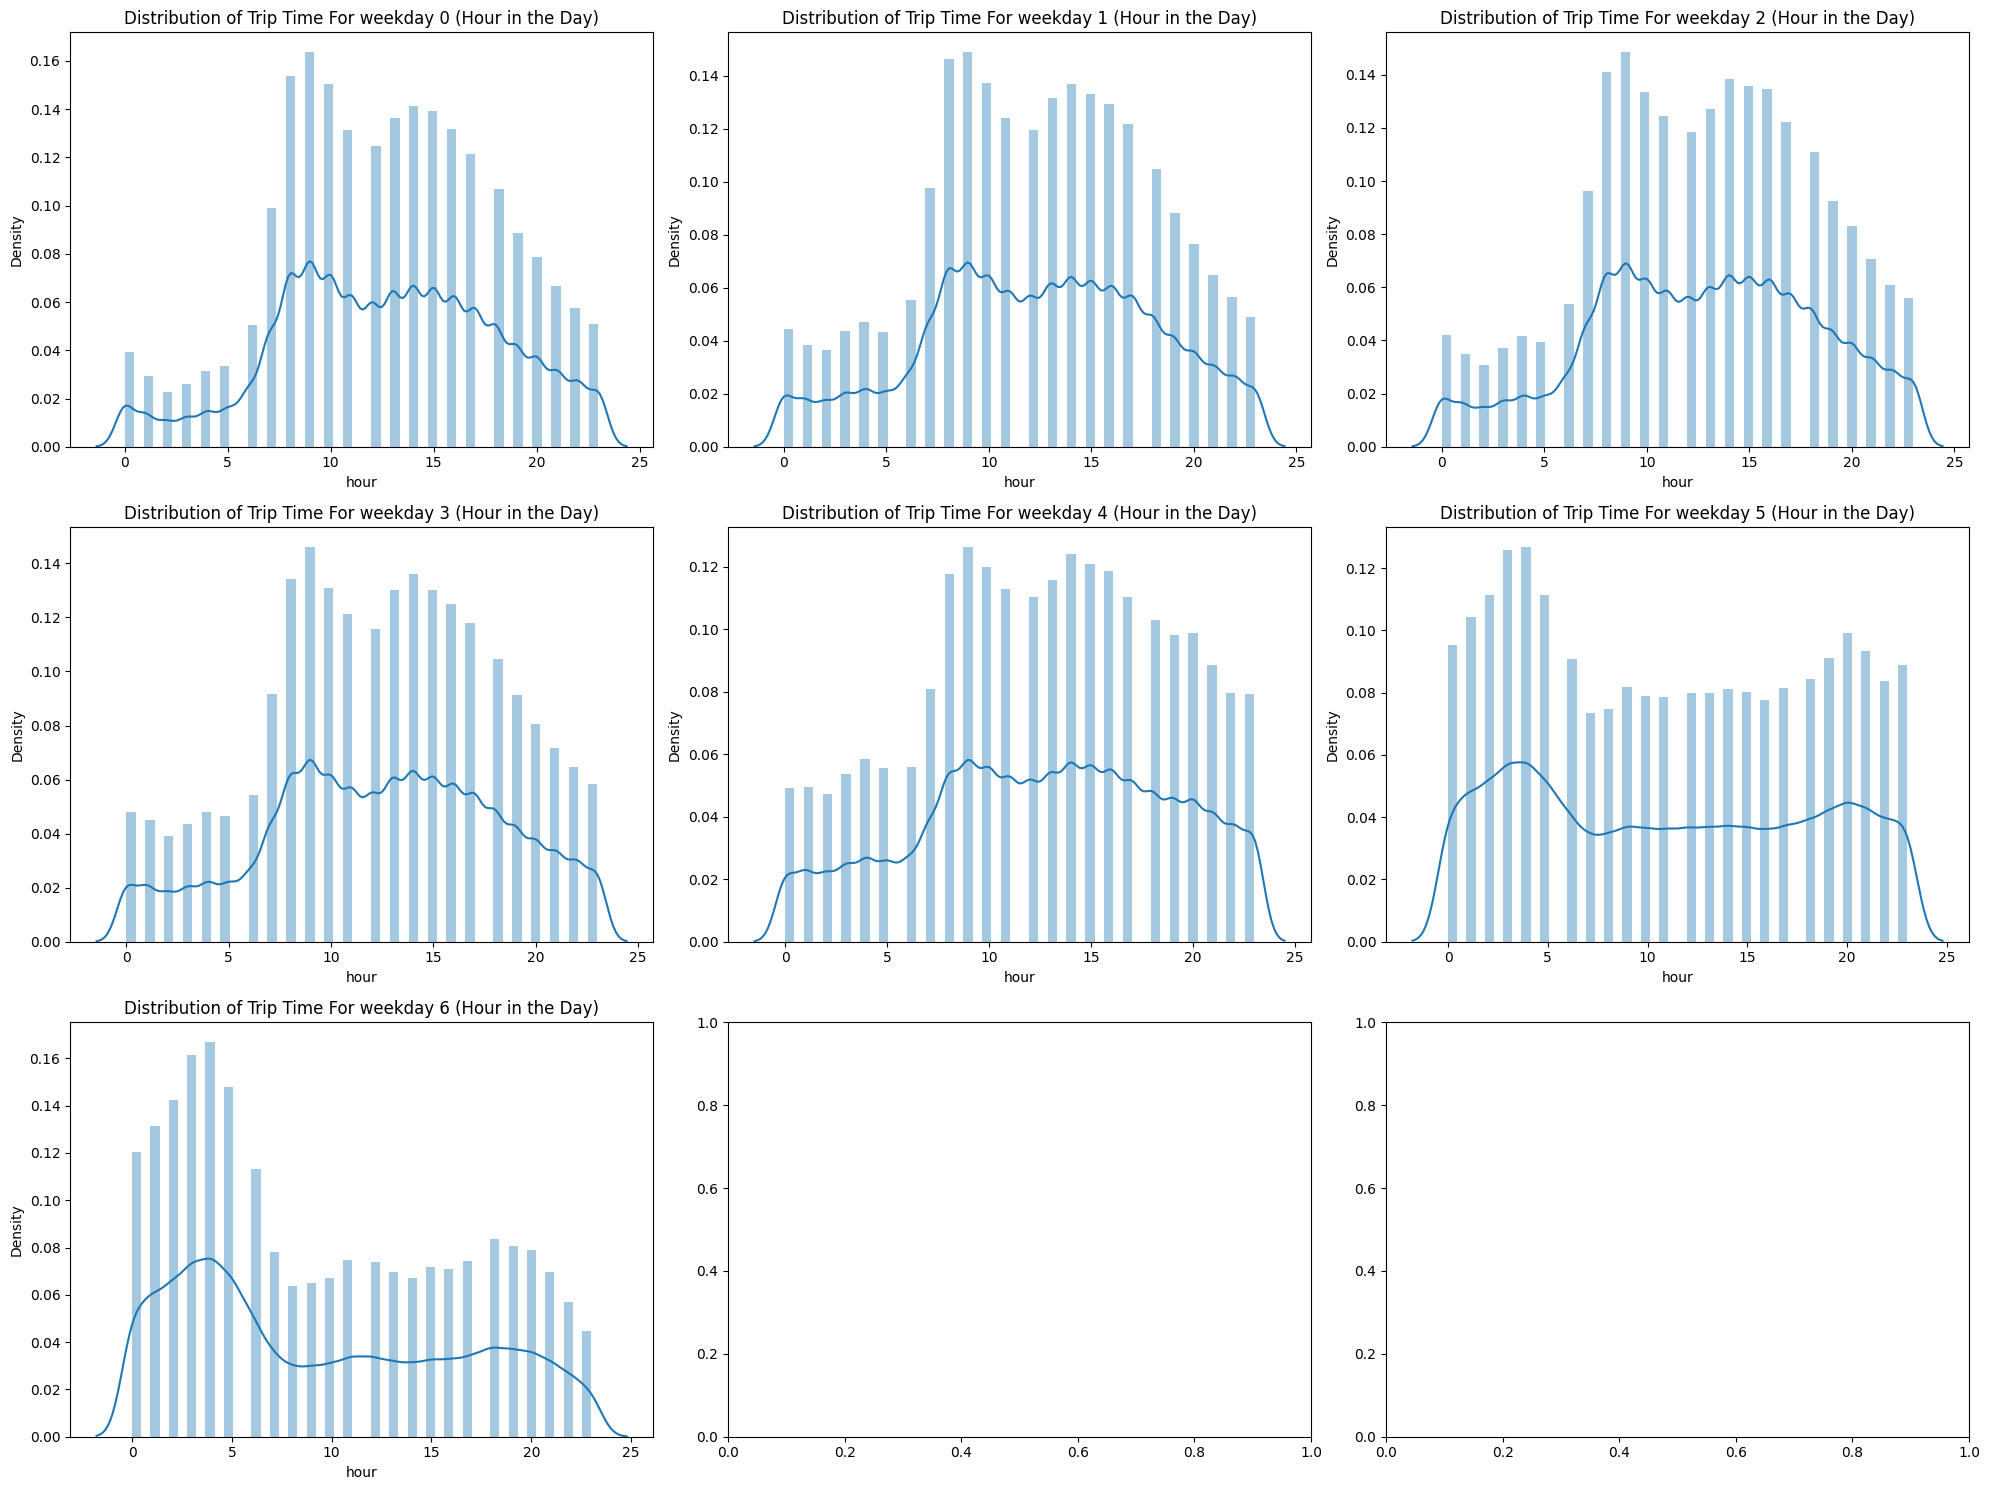

In [ ]:
# TIME SERIES STUDY
weekday = [0, 1, 2, 3, 4, 5, 6]

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20,15))
axs = axs.flatten()

for i, day in enumerate(weekday):
    # Filter for each month observations and reset index
    data2 = train.loc[train.weekday == day,:]
    sns.distplot(data2.hour, ax=axs[i])
    axs[i].set_title(f'Distribution of Trip Time For weekday {day} (Hour in the Day)')

plt.tight_layout()
plt.show()


Analizamos el volumen de viajes por día de la semana en todo el dataset (train)

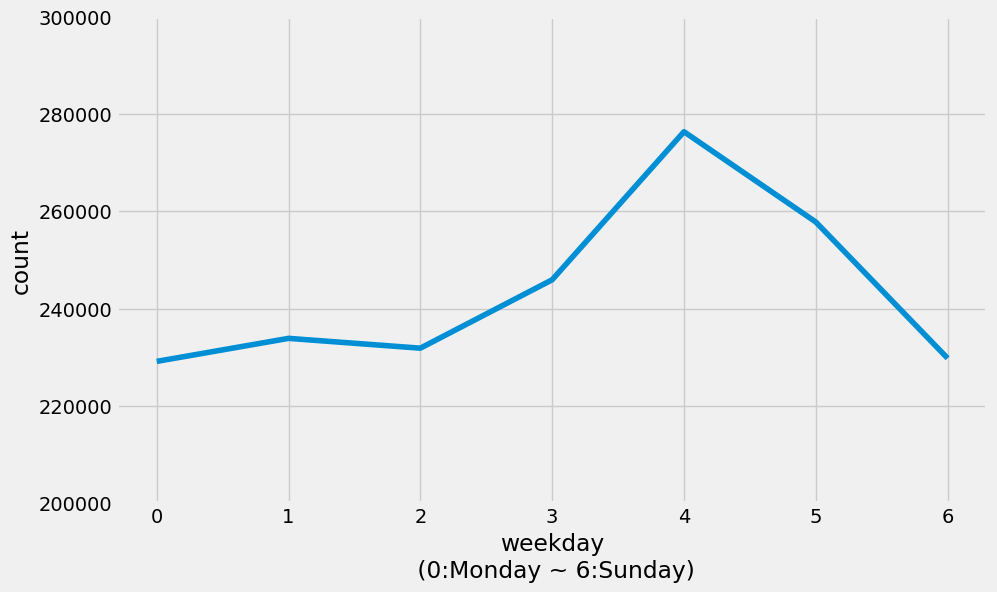

In [ ]:
# WEEKDAY GROUPBY ENTIRE DATA
weekday = pd.DataFrame(data=train.groupby("weekday").TRIP_ID.count()).reset_index()

with plt.style.context("fivethirtyeight"):
    plt.figure(figsize=(10,6))
    plt.plot(weekday["weekday"], weekday["TRIP_ID"])
    plt.xlabel("weekday\n (0:Monday ~ 6:Sunday)")
    plt.ylabel("count")
    plt.ylim([200000, 300000])

Nota:
- **Del gráfico de tiempo semanal agrupado anterior, podemos ver que la demanda máxima de los conductores es el viernes, seguida de una tendencia descendente pronunciada a medida que nos acercamos al fin de semana.**


Se realiza un análisis del tipo de llamada (CALL_TYPE):

Creamos una figura countplt con matplotlib de tamaño (10, 7) para la visualización.

seaborn.countplot() para contar la cantidad de viajes por cada tipo de llamada:

'A': Despachado desde la central.

'B': Solicitado directamente en una parada.

'C': Solicitado en la calle.

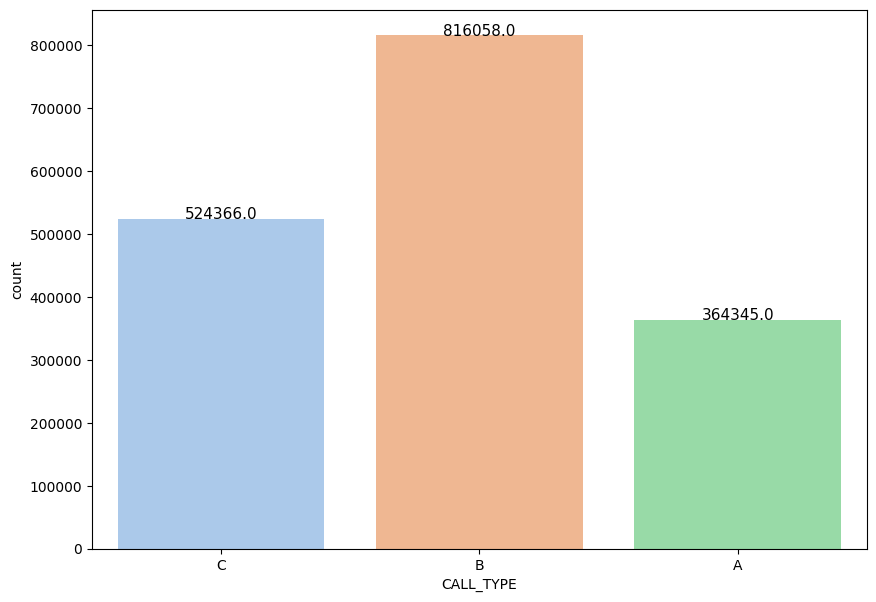

In [ ]:
# CALL TYPES STUDY
countplt, ax = plt.subplots(figsize = (10,7))
ax =sns.countplot(x = train['CALL_TYPE'],data=train,palette='pastel' )
for rect in ax.patches:
    ax.text (rect.get_x() + rect.get_width()  / 2,rect.get_height()+ 0.75,rect.get_height(),horizontalalignment='center', fontsize = 11)


Eliminamos la columna CALL_TYPE del DataFrame train.

In [ ]:
# DROPPING CALL_TYPE
del train['CALL_TYPE']

Reemplazamos los valores faltantes (NaN) en las columnas ORIGIN_CALL y ORIGIN_STAND por una cadena vacía ''

In [ ]:
# FILLING MISSING VALUES
train['ORIGIN_CALL'] = train[['ORIGIN_CALL']].fillna('')
train['ORIGIN_STAND'] = train[['ORIGIN_STAND']].fillna('')

 Creamos una copia independiente del DataFrame train y la guardamos en new_train

In [ ]:
# COPYING DATAFRAME
new_train = train.copy()
new_train

,TRIP_ID,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,month,...,hour,min,weekday,call_type_a,call_type_b,call_type_c,lon_1st,lat_1st,lon_last,lat_last
0,1372636858620000589,,,20000589,1.372637e+09,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[...",2013-07-01 00:00:58+00:00,2013,7,...,0,0,0,0,0,1,-8.618643,41.141412,-8.630838,41.154489
1,1372637303620000596,,7.0,20000596,1.372637e+09,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[...",2013-07-01 00:08:23+00:00,2013,7,...,0,8,0,0,1,0,-8.639847,41.159826,-8.665740,41.170671
2,1372636951620000320,,,20000320,1.372637e+09,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-...",2013-07-01 00:02:31+00:00,2013,7,...,0,2,0,0,0,1,-8.612964,41.140359,-8.615970,41.140530
3,1372636854620000520,,,20000520,1.372637e+09,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[...",2013-07-01 00:00:54+00:00,2013,7,...,0,0,0,0,0,1,-8.574678,41.151951,-8.607996,41.142915
4,1372637091620000337,,,20000337,1.372637e+09,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-...",2013-07-01 00:04:51+00:00,2013,7,...,0,4,0,0,0,1,-8.645994,41.180490,-8.687268,41.178087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710663,1388660427620000585,,,20000585,1.388660e+09,False,"[[-8.60697,41.162283],[-8.60697,41.16231],[-8....",2014-01-02 11:00:27+00:00,2014,1,...,11,0,3,0,0,1,-8.606970,41.162283,-8.608158,41.162382
1710665,1404171463620000698,,,20000698,1.404171e+09,False,"[[-8.612469,41.14602],[-8.612487,41.145993],[-...",2014-06-30 23:37:43+00:00,2014,6,...,23,37,0,0,0,1,-8.612469,41.146020,-8.611344,41.171013
1710666,1404171367620000670,,,20000670,1.404171e+09,False,"[[-8.610138,41.140845],[-8.610174,41.140935],[...",2014-06-30 23:36:07+00:00,2014,6,...,23,36,0,0,0,1,-8.610138,41.140845,-8.627454,41.158755
1710668,1404141826620000248,,12.0,20000248,1.404142e+09,False,"[[-8.630712,41.154885],[-8.63073,41.154813],[-...",2014-06-30 15:23:46+00:00,2014,6,...,15,23,0,0,1,0,-8.630712,41.154885,-8.587026,41.173524


Resumen estructural del DataFrame new_train

In [ ]:
new_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1704769 entries, 0 to 1710669
Data columns (total 21 columns):
 #   Column        Dtype              
---  ------        -----              
 0   TRIP_ID       int64              
 1   ORIGIN_CALL   object             
 2   ORIGIN_STAND  object             
 3   TAXI_ID       int64              
 4   TIMESTAMP     float64            
 5   MISSING_DATA  bool               
 6   POLYLINE      object             
 7   data_time     datetime64[ns, UTC]
 8   year          int32              
 9   month         int32              
 10  day           int32              
 11  hour          int32              
 12  min           int32              
 13  weekday       int32              
 14  call_type_a   int64              
 15  call_type_b   int64              
 16  call_type_c   int64              
 17  lon_1st       float64            
 18  lat_1st       float64            
 19  lon_last      float64            
 20  lat_last      float64        

Mostramos un heatmap (mapa de calor) de correlación entre variables numéricas del conjunto de datos new_train.

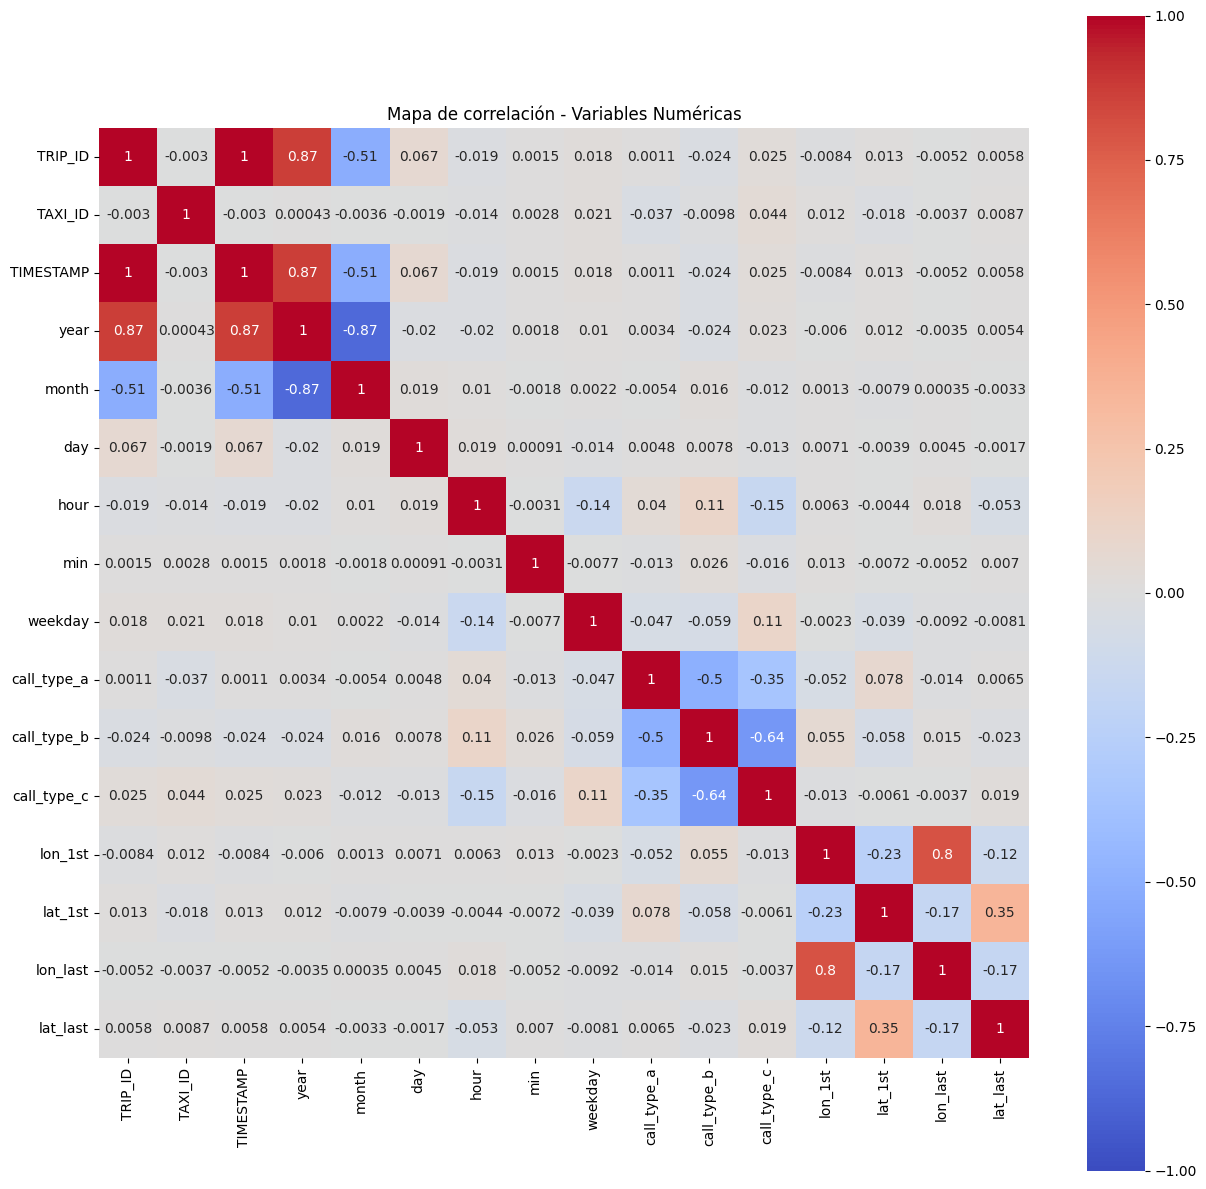

In [ ]:
# Seleccionar solo columnas numéricas
numeric_df = new_train.select_dtypes(include=['int64', 'int32', 'float64'])

# Graficar heatmap con esas columnas
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
sns.heatmap(numeric_df.corr(), annot=True, vmin=-1, vmax=1, center=0, cmap='coolwarm', square=True)
plt.title('Mapa de correlación - Variables Numéricas')
plt.show()

 Creamos un mapa interactivo de folium que visualiza el inicio y el final de los trayectos de taxi (usando las primeras 10.000 filas del DataFrame train)

In [ ]:
# PLOTTING A SAMPLE OF 1000 DATA POINTS.
mapping_1st = pd.DataFrame({
    "date":train.head(10000)["data_time"].values,
    "lat":train.head(10000)["lat_1st"].values,
    "lon":train.head(10000)["lon_1st"].values
})

mapping_last = pd.DataFrame({
    "date":train.head(10000)["data_time"].values,
    "lat":train.head(10000)["lat_last"].values,
    "lon":train.head(10000)["lon_last"].values
})

por_map = folium.Map(
    location=[41.141412, -8.590324],
    tiles="OpenStreetMap",
    zoom_start=11
)

for i, r in mapping_1st.iterrows():
    folium.CircleMarker(location=[r["lat"],r["lon"]], radius=0.5, color="red").add_to(por_map)

for i, r in mapping_last.iterrows():
    folium.CircleMarker(location=[r["lat"],r["lon"]], radius=0.5, color="blue").add_to(por_map)

por_map

#Modelos a usar

En esta sección, realizaremos pruebas en conjuntos de modelos para encontrar el mejor ajuste:
- Regresión lineal
- Regresor de bosque aleatorio
- Regresor de refuerzo de gradiente
- Regresor de K vecinos
- Regresión de cresta
- Regresor de árbol de decisión

In [ ]:
# CREATING DELTA PARAMETER FOR DISTANCE COMPUTATION FOR TRAINING DATA
train["delta_lon"] = train["lon_last"] - train["lon_1st"]
train["delta_lat"] = train["lat_last"] - train["lat_1st"]

In [ ]:
# CREATING DELTA PARAMETER FOR DISTANCE COMPUTATION FOR TEST DATA
# Creating Delta parameter for distance computation test data
test["delta_lon"] = test["lon_last"] - test["lon_1st"]
test["delta_lat"] = test["lat_last"] - test["lat_1st"]

In [ ]:
train

,TRIP_ID,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,month,...,weekday,call_type_a,call_type_b,call_type_c,lon_1st,lat_1st,lon_last,lat_last,delta_lon,delta_lat
0,1372636858620000589,,,20000589,1.372637e+09,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[...",2013-07-01 00:00:58+00:00,2013,7,...,0,0,0,1,-8.618643,41.141412,-8.630838,41.154489,-0.012195,0.013077
1,1372637303620000596,,7.0,20000596,1.372637e+09,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[...",2013-07-01 00:08:23+00:00,2013,7,...,0,0,1,0,-8.639847,41.159826,-8.665740,41.170671,-0.025893,0.010845
2,1372636951620000320,,,20000320,1.372637e+09,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-...",2013-07-01 00:02:31+00:00,2013,7,...,0,0,0,1,-8.612964,41.140359,-8.615970,41.140530,-0.003006,0.000171
3,1372636854620000520,,,20000520,1.372637e+09,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[...",2013-07-01 00:00:54+00:00,2013,7,...,0,0,0,1,-8.574678,41.151951,-8.607996,41.142915,-0.033318,-0.009036
4,1372637091620000337,,,20000337,1.372637e+09,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-...",2013-07-01 00:04:51+00:00,2013,7,...,0,0,0,1,-8.645994,41.180490,-8.687268,41.178087,-0.041274,-0.002403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710663,1388660427620000585,,,20000585,1.388660e+09,False,"[[-8.60697,41.162283],[-8.60697,41.16231],[-8....",2014-01-02 11:00:27+00:00,2014,1,...,3,0,0,1,-8.606970,41.162283,-8.608158,41.162382,-0.001188,0.000099
1710665,1404171463620000698,,,20000698,1.404171e+09,False,"[[-8.612469,41.14602],[-8.612487,41.145993],[-...",2014-06-30 23:37:43+00:00,2014,6,...,0,0,0,1,-8.612469,41.146020,-8.611344,41.171013,0.001125,0.024993
1710666,1404171367620000670,,,20000670,1.404171e+09,False,"[[-8.610138,41.140845],[-8.610174,41.140935],[...",2014-06-30 23:36:07+00:00,2014,6,...,0,0,0,1,-8.610138,41.140845,-8.627454,41.158755,-0.017316,0.017910
1710668,1404141826620000248,,12.0,20000248,1.404142e+09,False,"[[-8.630712,41.154885],[-8.63073,41.154813],[-...",2014-06-30 15:23:46+00:00,2014,6,...,0,0,1,0,-8.630712,41.154885,-8.587026,41.173524,0.043686,0.018639


In [ ]:
test

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,MISSING_DATA,POLYLINE,data_time,year,...,weekday,call_type_a,call_type_b,call_type_c,lon_1st,lat_1st,lon_last,lat_last,delta_lon,delta_lat
0,T1,B,NaN,15.0,20000542,1.408039e+09,False,"[[-8.585676,41.148522],[-8.585712,41.148639],[...",2014-08-14 17:57:17+00:00,2014,...,3,0,1,0,-8.585676,41.148522,-8.584884,41.146623,0.000792,-0.001899
1,T2,B,NaN,57.0,20000108,1.408039e+09,False,"[[-8.610876,41.14557],[-8.610858,41.145579],[-...",2014-08-14 17:50:11+00:00,2014,...,3,0,1,0,-8.610876,41.145570,-8.601894,41.163597,0.008982,0.018027
2,T3,B,NaN,15.0,20000370,1.408039e+09,False,"[[-8.585739,41.148558],[-8.58573,41.148828],[-...",2014-08-14 17:49:28+00:00,2014,...,3,0,1,0,-8.585739,41.148558,-8.574903,41.167719,0.010836,0.019161
3,T4,B,NaN,53.0,20000492,1.408039e+09,False,"[[-8.613963,41.141169],[-8.614125,41.141124],[...",2014-08-14 17:58:10+00:00,2014,...,3,0,1,0,-8.613963,41.141169,-8.614638,41.140980,-0.000675,-0.000189
4,T5,B,NaN,18.0,20000621,1.408039e+09,False,"[[-8.619903,41.148036],[-8.619894,41.148036]]",2014-08-14 17:59:37+00:00,2014,...,3,0,1,0,-8.619903,41.148036,-8.619894,41.148036,0.000009,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,T323,A,70885.0,NaN,20000430,1.419171e+09,False,"[[-8.570196,41.159484],[-8.570187,41.158962],[...",2014-12-21 14:18:05+00:00,2014,...,6,1,0,0,-8.570196,41.159484,-8.593308,41.151051,-0.023112,-0.008433
316,T324,B,NaN,53.0,20000020,1.419171e+09,False,"[[-8.613873,41.141232],[-8.613882,41.141241],[...",2014-12-21 14:06:42+00:00,2014,...,6,0,1,0,-8.613873,41.141232,-8.629785,41.152671,-0.015912,0.011439
317,T325,C,NaN,NaN,20000207,1.419172e+09,False,"[[-8.6481,41.152536],[-8.647461,41.15241],[-8....",2014-12-21 14:28:41+00:00,2014,...,6,0,0,1,-8.648100,41.152536,-8.643303,41.154327,0.004797,0.001791
318,T326,A,76232.0,NaN,20000667,1.419172e+09,False,"[[-8.571699,41.156073],[-8.570583,41.155929],[...",2014-12-21 14:26:20+00:00,2014,...,6,1,0,0,-8.571699,41.156073,-8.569206,41.167629,0.002493,0.011556


In [ ]:
# COPYING DATAFRAME FOR MODEL TRAINING
ml_train = train.copy()

# Origin_call
def origin_call_flg(x):
    if x["ORIGIN_CALL"] == None:
        res = 0
    else:
        res = 1
    return res
ml_train["ORIGIN_CALL"] = ml_train.apply(origin_call_flg, axis=1)

# Origin_stand
def origin_stand_flg(x):
    if x["ORIGIN_STAND"] == None:
        res = 0
    else:
        res=1
    return res
ml_train["ORIGIN_STAND"] = ml_train.apply(origin_stand_flg, axis=1)


# Missing data
def miss_flg(x):
    if x["MISSING_DATA"] == "False":
        res = 0
    else:
        res = 1
    return res
ml_train["MISSING_DATA"] = ml_train.apply(miss_flg, axis=1)

In [ ]:
# COPYING DATAFRAME FOR MODEL TESTING
ml_test = test.copy()

# Origin_call
def origin_call_flg(x):
    if x["ORIGIN_CALL"] == None:
        res = 0
    else:
        res = 1
    return res
ml_test["ORIGIN_CALL"] = ml_test.apply(origin_call_flg, axis=1)

# Origin_stand
def origin_stand_flg(x):
    if x["ORIGIN_STAND"] == None:
        res = 0
    else:
        res=1
    return res
ml_test["ORIGIN_STAND"] = ml_test.apply(origin_stand_flg, axis=1)


# Missing data
def miss_flg(x):
    if x["MISSING_DATA"] == "False":
        res = 0
    else:
        res = 1
    return res
ml_test["MISSING_DATA"] = ml_test.apply(miss_flg, axis=1)

In [ ]:
ml_train = ml_train.sample(136000) # A random sampling of 136000(*%) of data point will be used to train as 1.7M is large

In [ ]:
X = ml_train[["call_type_a","call_type_b","call_type_c",'ORIGIN_CALL','ORIGIN_STAND', 'MISSING_DATA', 'lon_1st', 'lat_1st', 'delta_lon', 'delta_lat']]

In [ ]:
y = ml_train[["lon_last","lat_last"]]

In [ ]:
X_Test = ml_test[["call_type_a","call_type_b","call_type_c",'ORIGIN_CALL','ORIGIN_STAND', 'MISSING_DATA', 'lon_1st', 'lat_1st', 'delta_lon', 'delta_lat']]

In [ ]:
# TRAIN, TEST SPIT 70 % FOR TRAINING & 30 % FOR TESTING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
# LINEAR REGRESSION MODEL

lr = MultiOutputRegressor(LinearRegression(n_jobs=1))

# Fitting
lr = lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [ ]:
# RANDOMFOREST REGRESSOR MODEL

forest = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=1))

# Fitting
forest = forest.fit(X_train, y_train)
y_train_pred2 = forest.predict(X_train)
y_test_pred2 = forest.predict(X_test)


In [ ]:
# GRADIENTBOOSTING REGRESSOR MODEL

bosting = MultiOutputRegressor(GradientBoostingRegressor(random_state=0))

# Fitting
bosting = bosting.fit(X_train, y_train)
y_train_pred3 = bosting.predict(X_train)
y_test_pred3 = bosting.predict(X_test)


In [ ]:
# KNEIGHBORS REGRESSOR MODEL

knn = MultiOutputRegressor(KNeighborsRegressor())

# Fitting
knn = knn.fit(X_train, y_train)
y_train_pred4 = knn.predict(X_train)
y_test_pred4 = knn.predict(X_test)

In [ ]:
# RIDGE REGRESSION MODEL

reg = MultiOutputRegressor(linear_model.Ridge())

# Fitting
knn = reg.fit(X_train, y_train)
y_train_pred5 = reg.predict(X_train)
y_test_pred5 = reg.predict(X_test)

In [ ]:
# DECISIONTREE REGRESSOR MODEL

dt = MultiOutputRegressor(DecisionTreeRegressor(max_depth=50, random_state=1))

# Fitting
dt = dt.fit(X_train, y_train)
y_train_pred6 = dt.predict(X_train)
y_test_pred6 = dt.predict(X_test)


# Evaluación de modelos

**En esta sección, evaluaremos todos los modelos para encontrar el mejor ajuste:**

*Las siguientes son las métricas que se utilizarán para evaluar nuestros modelos:*

- El Error Cuadrático Medio (MSE) es el promedio de las diferencias al cuadrado entre los valores predichos y los valores reales para un conjunto de datos.

La fórmula para el MSE es:

MSE = (1/n) * Σ (y_pred - y_true)^2

- El R cuadrado (R²), también conocido como coeficiente de determinación, se utiliza para evaluar el rendimiento de los modelos de aprendizaje automático de regresión. Mide la proporción de la varianza en la variable dependiente que es predecible a partir de la(s) variable(s) independiente(s). El R² varía de 0 a 1, donde 1 indica que el modelo se ajusta perfectamente a los datos y 0 indica que el modelo no explica la variabilidad de los datos.
La fórmula para R² es:
R² = 1 - (SSE/SST)


In [ ]:
# EVALUATION FOR LINEAR REGRESSION

print("Mean Square Error on training Data:{}".format(mean_squared_error(y_train, y_train_pred)))
print("Mean Square Error on testing Data:{}".format(mean_squared_error(y_test, y_test_pred)))
print("R2 score train:{}".format(r2_score(y_train, y_train_pred)))
print("R2 score test:{}".format(r2_score(y_test, y_test_pred)))
y_Test_pred = lr.predict(X_Test)

Mean Square Error on training Data:2.6822140844689277e-29
Mean Square Error on testing Data:2.682069073273115e-29
R2 score train:1.0
R2 score test:1.0


In [ ]:
# EVALUATION FOR RANDOMFOREST REGRESSOR

print("MSE train:{}".format(mean_squared_error(y_train, y_train_pred2)))
print("MSE test;{}".format(mean_squared_error(y_test, y_test_pred2)))
print("R2 score train:{}".format(r2_score(y_train, y_train_pred2)))
print("R2 score test:{}".format(r2_score(y_test, y_test_pred2)))

y_Test_pred2 = forest.predict(X_Test)
y_Test_pred2[2]

MSE train:3.3435470791805965e-05
MSE test;3.00245114621042e-05
R2 score train:0.9793001474331551
R2 score test:0.9827885549857859


array([-8.57488428, 41.16772764])

In [ ]:
# EVALUATION FOR GRADIENTBOOSTING REGRESSOR

print("Mean Square Error on training Data:{}".format(mean_squared_error(y_train, y_train_pred3)))
print("Mean Square Error on testing Data:{}".format(mean_squared_error(y_test, y_test_pred3)))
print("R2 score train:{}".format(r2_score(y_train, y_train_pred3)))
print("R2 score test:{}".format(r2_score(y_test, y_test_pred3)))
y_Test_pred3 = bosting.predict(X_Test)
y_Test_pred3[3]

Mean Square Error on training Data:4.212339817271819e-06
Mean Square Error on testing Data:1.646594742720652e-05
R2 score train:0.9973028287020593
R2 score test:0.9900600642345296


array([-8.61628181, 41.14177907])

In [ ]:
# EVALUATION FOR KNEIGHBORS REGRESSOR

print("Mean Square Error on training Data:{}".format(mean_squared_error(y_train, y_train_pred4)))
print("Mean Square Error on testing Data:{}".format(mean_squared_error(y_test, y_test_pred4)))
print("R2 score train:{}".format(r2_score(y_train, y_train_pred4)))
print("R2 score test:{}".format(r2_score(y_test, y_test_pred4)))
y_Test_pred4 = bosting.predict(X_Test)
y_Test_pred4[4]

Mean Square Error on training Data:0.00018744226924696442
Mean Square Error on testing Data:7.83884268387797e-05
R2 score train:0.8862098000363703
R2 score test:0.9538147406493352


array([-8.62101492, 41.1476297 ])

In [ ]:
# EVALUATION FOR RIDGE REGRESSION

print("Mean Square Error on training Data:{}".format(mean_squared_error(y_train, y_train_pred5)))
print("Mean Square Error on testing Data:{}".format(mean_squared_error(y_test, y_test_pred5)))
print("R2 score train:{}".format(r2_score(y_train, y_train_pred5)))
print("R2 score test:{}".format(r2_score(y_test, y_test_pred5)))
y_Test_pred5 = reg.predict(X_Test)
y_Test_pred5[5]

Mean Square Error on training Data:3.289287016443892e-07
Mean Square Error on testing Data:3.2732369827844855e-07
R2 score train:0.9997849936230269
R2 score test:0.9998096434131835


array([-8.62641867, 41.17163428])

In [ ]:
# EVALUATION FOR DECISIONTREE REGRESSOR

print("Mean Square Error on training Data:{}".format(mean_squared_error(y_train, y_train_pred6)))
print("Mean Square Error on testing Data:{}".format(mean_squared_error(y_test, y_test_pred6)))
print("R2 score train:{}".format(r2_score(y_train, y_train_pred6)))
print("R2 score test:{}".format(r2_score(y_test, y_test_pred6)))
y_Test_pred6 = dt.predict(X_Test)
y_Test_pred6[5]

Mean Square Error on training Data:0.0
Mean Square Error on testing Data:5.5174654321875135e-05
R2 score train:1.0
R2 score test:0.9687148099429321


array([-8.626545, 41.172543])

# Predecir y preparar para Kaggle

- **De los modelos anteriores pudimos ver que la regresión lineal tiene el mejor desempeño, por lo tanto, la utilizaremos para nuestra presentación final.**

In [ ]:
# PREPARING FOR SUBMISSION

submit_lat = y_Test_pred.T[1]
submit_lon = y_Test_pred.T[0]

In [ ]:
# CREATING THE SUBMISSION DATA FORMAT

submit = pd.DataFrame({"TRIP_ID":test["TRIP_ID"], "LATITUDE":submit_lat, "LONGITUDE":submit_lon})

In [ ]:
# FINAL SUBMISSION

submit.to_csv('submission.csv', index=False)
sub = pd.read_csv("./submission.csv")
sub.head(5)

,TRIP_ID,LATITUDE,LONGITUDE
0,T1,41.146623,-8.584884
1,T2,41.163597,-8.601894
2,T3,41.167719,-8.574903
3,T4,41.140980,-8.614638
4,T5,41.148036,-8.619894
